# Part 2 — Image-Level Predictors of Consistency

Tests what distinguishes a highly-consistent image from a poorly-consistent
one. Two candidate predictors are tested: response sparsity/magnitude (neural,
from Part 1 outputs) and CNN-based image complexity (ResNet50 layer embeddings,
from the preprocessed archive). Partial Spearman correlation establishes
whether CNN complexity predicts consistency *independently* of sparsity.

**Depends on:** `part1_outputs.npz`, `cnn_embeddings.npz`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')
COL_NS  = 'steelblue'
COL_GR  = 'darkorange'
COL_FIT = 'firebrick'
COL_REF = 'dimgray'


colors  = apply_plot_style()
COL_NS  = colors["COL_NS"]
COL_GR  = colors["COL_GR"]
COL_FIT = colors["COL_FIT"]
COL_REF = colors["COL_REF"]

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES = manifest['n_images']

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
consistency    = p1['consistency']       # (118,)
mean_sparsity  = p1['mean_sparsity']    # (118,)
mean_magnitude = p1['mean_magnitude']   # (118,)

cnn_data    = np.load(ARCHIVE_DIR / 'cnn_embeddings.npz')
layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'final']
layer_emb   = {name: cnn_data[name] for name in layer_names}

print(f'Images: {N_IMAGES}')
print(f'Consistency range: [{consistency.min():.3f}, {consistency.max():.3f}]')
print(f'CNN layers: {[(k, v.shape) for k, v in layer_emb.items()]}')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Images: 118
Consistency range: [0.142, 0.588]
CNN layers: [('layer1', (118, 256)), ('layer2', (118, 512)), ('layer3', (118, 1024)), ('layer4', (118, 2048)), ('final', (118, 1000))]


## 2.1 — Sparsity and magnitude as image-level predictors

Sparsity is defined as the fraction of units responding below the per-mouse
median absolute z-score — a threshold-free measure robust to session-level
differences in overall firing rate. Both predictors were averaged across mice
(already done in Part 1) before correlating with consistency.

In [3]:
r_sp,  p_sp  = spearmanr(consistency, mean_sparsity)
r_mag, p_mag = spearmanr(consistency, mean_magnitude)
print(f'Consistency vs. sparsity  : r = {r_sp:+.3f},  p = {p_sp:.2e}')
print(f'Consistency vs. magnitude : r = {r_mag:+.3f},  p = {p_mag:.2e}')

Consistency vs. sparsity  : r = -0.470,  p = 7.84e-08
Consistency vs. magnitude : r = +0.276,  p = 2.51e-03


## 2.2 — CNN feature embeddings

ResNet50 pretrained on ImageNet (IMAGENET1K_V2) is used as a feature
extractor. Global average pooling reduces each convolutional block to a
fixed-length vector per image. Ridge LOO regression (n=118 images) is used
because feature dimension >> n_images makes OLS ill-posed.

Partial Spearman correlation tests whether CNN complexity predicts consistency
*after controlling for sparsity*, using rank-residualisation.

In [4]:
CNN_PRIMARY = 'layer2'   # best single-layer predictor

layer_results = {}
for name, emb in layer_emb.items():
    Xs     = StandardScaler().fit_transform(emb)
    loo    = LeaveOneOut()
    y_pred = cross_val_predict(
        RidgeCV(alphas=np.logspace(-2, 6, 30)), Xs, consistency, cv=loo)
    r, p   = pearsonr(consistency, y_pred)
    layer_results[name] = {'r': r, 'r2': r**2, 'p': p, 'y_pred': y_pred}
    print(f'{name:>8s}: LOO r = {r:+.3f},  R² = {r**2:.3f},  p = {p:.2e}')


def partial_spearman(x, y, cov):
    """Non-parametric partial correlation via rank-residualisation."""
    def resid(a, b):
        ar = pd.Series(a).rank().values.astype(float)
        br = pd.Series(b).rank().values.astype(float)
        return ar - LinearRegression().fit(
            br.reshape(-1, 1), ar).predict(br.reshape(-1, 1))
    return spearmanr(resid(x, cov), resid(y, cov))


cnn_proxy   = layer_emb[CNN_PRIMARY].mean(axis=1)   # scalar per image
r_raw, p_raw = spearmanr(cnn_proxy, consistency)
r_par, p_par = partial_spearman(cnn_proxy, consistency, mean_sparsity)

print(f'\n{CNN_PRIMARY} mean activation vs consistency:')
print(f'  Raw Spearman r            : {r_raw:+.3f},  p = {p_raw:.2e}')
print(f'  Partial r (sparsity ctrl) : {r_par:+.3f},  p = {p_par:.2e}')

  layer1: LOO r = -0.298,  R² = 0.089,  p = 1.03e-03
  layer2: LOO r = -0.496,  R² = 0.246,  p = 1.11e-08
  layer3: LOO r = -0.182,  R² = 0.033,  p = 4.90e-02
  layer4: LOO r = -0.243,  R² = 0.059,  p = 8.09e-03
   final: LOO r = -0.486,  R² = 0.236,  p = 2.48e-08

layer2 mean activation vs consistency:
  Raw Spearman r            : -0.017,  p = 8.55e-01
  Partial r (sparsity ctrl) : +0.094,  p = 3.13e-01


## Added-variable analysis

Added-variable plots show the partial effect of each predictor after
controlling for the other, confirming sparsity retains an independent
effect while CNN features do not.

In [5]:
def ols_resid(y, x):
    """Residuals of y ~ x (OLS, with intercept)."""
    X_ = np.column_stack([np.ones(len(x)), x])
    b  = np.linalg.lstsq(X_, y, rcond=None)[0]
    return y - X_ @ b

resid_cons_vs_cnn     = ols_resid(consistency,  cnn_proxy)
resid_sp_vs_cnn       = ols_resid(mean_sparsity, cnn_proxy)
resid_cons_vs_sp      = ols_resid(consistency,  mean_sparsity)
resid_cnn_vs_sp       = ols_resid(cnn_proxy,     mean_sparsity)

r_av_sp,  _ = pearsonr(resid_sp_vs_cnn,  resid_cons_vs_cnn)
r_av_cnn, _ = pearsonr(resid_cnn_vs_sp,  resid_cons_vs_sp)
print(f'Added-variable partial r — sparsity | CNN : {r_av_sp:+.3f}')
print(f'Added-variable partial r — CNN | sparsity : {r_av_cnn:+.3f}')

Added-variable partial r — sparsity | CNN : -0.527
Added-variable partial r — CNN | sparsity : +0.117


---
## Figures

**Fig. 2** — Response sparsity, not image complexity, predicts cross-mouse consistency.
**S2** — CNN layer comparison and partial-regression detail.


Fig 2A — consistency vs. response sparsity

--- mean_sparsity ---
shape=(118,)
[0.520492 0.546472 0.482891 0.457203 0.508473 0.426674 0.487684 0.54445  0.519074 0.517934 0.565284 0.59953  0.554183 0.459788 0.480241 0.480375 0.515295 0.42606  0.433015 0.412091]
...[118 elements total]

--- consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163267 0.260908 0.19579  0.275605 0.248535 0.290777 0.303716 0.260574 0.379713 0.378248 0.45102  0.32783  0.369047]
...[118 elements total]

--- spearman_r ---
-0.47008790478381707

--- spearman_p ---
7.837762738778081e-08

Fig 2B — consistency vs. response magnitude

--- mean_magnitude ---
shape=(118,)
[0.622436 0.661972 0.758902 0.881167 0.644245 0.967838 0.806265 0.688401 0.752618 0.738666 0.623841 0.584964 0.625305 0.868559 0.752002 0.840273 0.762268 0.911898 0.876095 1.054934]
...[118 elements total]

--- consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163

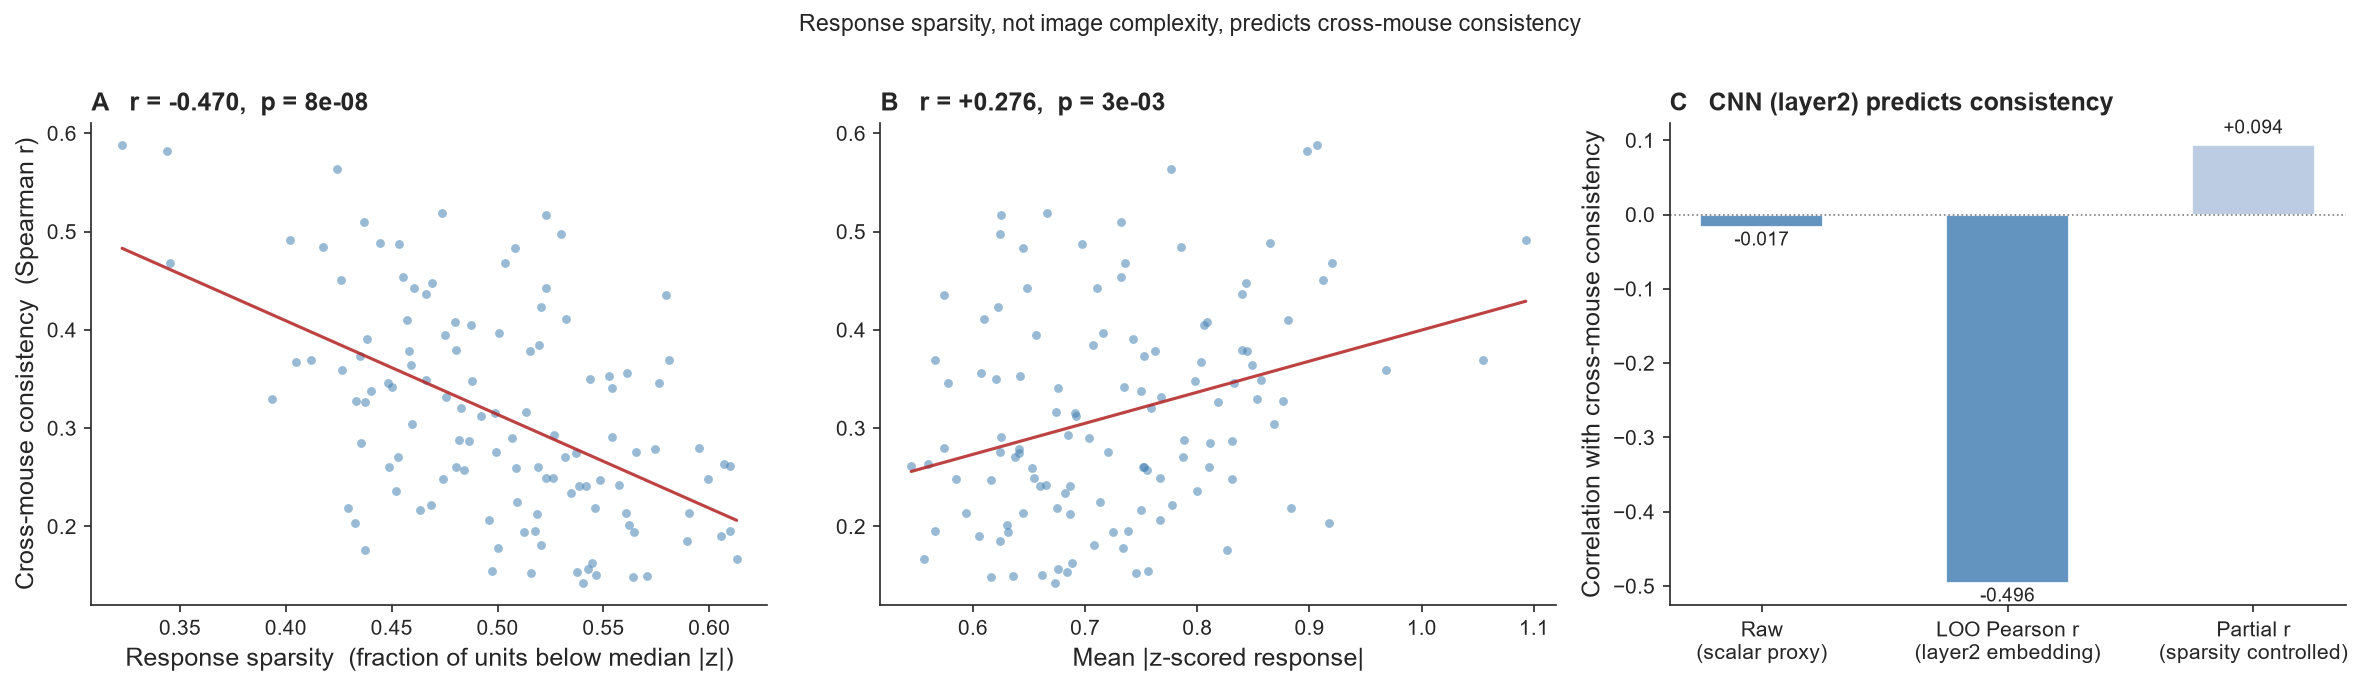

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

def scatter_with_fit(ax, x, y, r, p, xlabel, title_letter, color=COL_NS):
    ax.scatter(x, y, s=18, alpha=0.55, color=color, linewidths=0)
    m, b = np.polyfit(x, y, 1)
    xr   = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color=COL_FIT, linewidth=1.5, alpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{title_letter}   r = {r:+.3f},  p = {p:.0e}',
                 loc='left', fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Cross-mouse consistency  (Spearman r)')

scatter_with_fit(axes[0], mean_sparsity, consistency, r_sp, p_sp,
                 'Response sparsity  (fraction of units below median |z|)', 'A')
scatter_with_fit(axes[1], mean_magnitude, consistency, r_mag, p_mag,
                 'Mean |z-scored response|', 'B')

# Panel C: bar comparing LOO r vs. partial r for CNN
ax = axes[2]
bar_vals   = [r_raw, layer_results[CNN_PRIMARY]['r'], r_par]
bar_labels = ['Raw\n(scalar proxy)', f'LOO Pearson r\n({CNN_PRIMARY} embedding)',
              'Partial r\n(sparsity controlled)']
bar_colors = [COL_NS if abs(v) > 0.1 and p_raw < 0.05 else 'lightsteelblue'
              for v in bar_vals]
bar_colors = [COL_NS, COL_NS, 'lightsteelblue']   # LOO sig, partial n.s.
bars = ax.bar(bar_labels, bar_vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + (0.01 if v >= 0 else -0.03),
            f'{v:+.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_ylabel('Correlation with cross-mouse consistency')
ax.set_title(f'C   CNN ({CNN_PRIMARY}) predicts consistency',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Response sparsity, not image complexity, predicts cross-mouse consistency',
             fontsize=11, y=1.01)

print_figure_data(
    'Fig 2A — consistency vs. response sparsity',
    mean_sparsity=mean_sparsity,
    consistency=consistency,
    spearman_r=r_sp,
    spearman_p=p_sp,
)
print_figure_data(
    'Fig 2B — consistency vs. response magnitude',
    mean_magnitude=mean_magnitude,
    consistency=consistency,
    spearman_r=r_mag,
    spearman_p=p_mag,
)
print_figure_data(
    f'Fig 2C — CNN ({CNN_PRIMARY}) correlation comparison (raw vs. LOO vs. partial)',
    bar_labels=bar_labels,
    bar_values=np.array(bar_vals),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_image_predictors.pdf', bbox_inches='tight')
plt.show()


Fig S2A — LOO Pearson r per ResNet50 layer

--- layer_names ---
['layer1', 'layer2', 'layer3', 'layer4', 'final']

--- loo_r_per_layer ---
[-0.298384 -0.496136 -0.18166  -0.242732 -0.485694]

--- p_per_layer ---
[0.001031 0.       0.048983 0.008087 0.      ]

Fig S2B — added-variable plots (sparsity | CNN and CNN | sparsity)

--- sparsity_residual_given_cnn ---
shape=(118,)
[ 0.025592  0.0447   -0.019498 -0.048612  0.020557 -0.060964 -0.014151  0.050613  0.01233   0.009283  0.060623  0.07876   0.059793 -0.029991 -0.020933 -0.019225  0.005364 -0.078142 -0.065782
 -0.057987]
...[118 elements total]

--- consistency_residual_given_cnn ---
shape=(118,)
[ 0.107371 -0.163265  0.006743  0.097448  0.1655    0.041734  0.091425 -0.152529 -0.051336 -0.115929 -0.037212 -0.059848 -0.024866 -0.013196 -0.053203  0.065503  0.066881  0.138076  0.013399
  0.046713]
...[118 elements total]

--- partial_r_sparsity_given_cnn ---
-0.5270327281652751

--- cnn_residual_given_sparsity ---
shape=(118,)
[-0.017

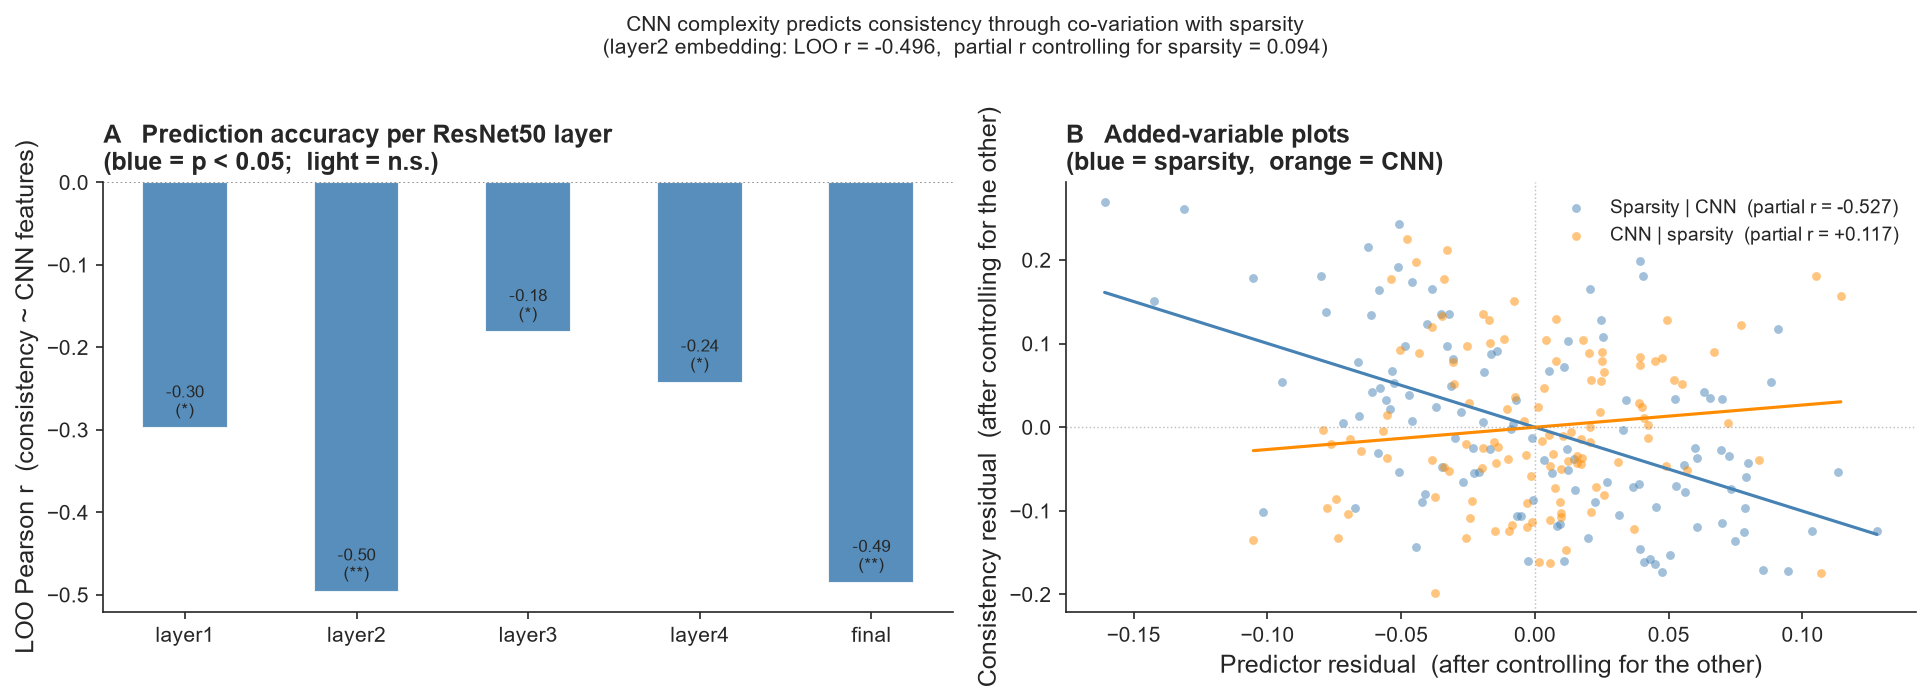

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: LOO r per layer
ax = axes[0]
r_vals  = [layer_results[l]['r'] for l in layer_names]
p_vals  = [layer_results[l]['p'] for l in layer_names]
colors  = [COL_NS if p < 0.05 else 'lightsteelblue' for p in p_vals]
bars = ax.bar(layer_names, r_vals, color=colors, alpha=0.9, width=0.5)
for bar, r, p in zip(bars, r_vals, p_vals):
    sig = '**' if p < 0.001 else ('*' if p < 0.05 else 'n.s.')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{r:.2f}\n({sig})', ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_ylabel('LOO Pearson r  (consistency ~ CNN features)')
ax.set_title('A   Prediction accuracy per ResNet50 layer\n'
             '(blue = p < 0.05;  light = n.s.)',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

# Panel B: added-variable plots
ax = axes[1]
ax.scatter(resid_sp_vs_cnn, resid_cons_vs_cnn, s=18, alpha=0.5,
           color=COL_NS, linewidths=0,
           label=f'Sparsity | CNN  (partial r = {r_av_sp:+.3f})')
m, b = np.polyfit(resid_sp_vs_cnn, resid_cons_vs_cnn, 1)
xr   = np.linspace(resid_sp_vs_cnn.min(), resid_sp_vs_cnn.max(), 100)
ax.plot(xr, m*xr+b, color=COL_NS, linewidth=1.5)

ax.scatter(resid_cnn_vs_sp, resid_cons_vs_sp, s=18, alpha=0.5,
           color=COL_GR, linewidths=0,
           label=f'CNN | sparsity  (partial r = {r_av_cnn:+.3f})')
m2, b2 = np.polyfit(resid_cnn_vs_sp, resid_cons_vs_sp, 1)
xr2    = np.linspace(resid_cnn_vs_sp.min(), resid_cnn_vs_sp.max(), 100)
ax.plot(xr2, m2*xr2+b2, color=COL_GR, linewidth=1.5)

ax.axhline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Predictor residual  (after controlling for the other)')
ax.set_ylabel('Consistency residual  (after controlling for the other)')
ax.set_title('B   Added-variable plots\n(blue = sparsity,  orange = CNN)',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'CNN complexity predicts consistency through co-variation with sparsity\n'
             f'({CNN_PRIMARY} embedding: LOO r = {layer_results[CNN_PRIMARY]["r"]:.3f},  '
             f'partial r controlling for sparsity = {r_par:.3f})',
             fontsize=10, y=1.02)

print_figure_data(
    'Fig S2A — LOO Pearson r per ResNet50 layer',
    layer_names=layer_names,
    loo_r_per_layer=np.array(r_vals),
    p_per_layer=np.array(p_vals),
)
print_figure_data(
    'Fig S2B — added-variable plots (sparsity | CNN and CNN | sparsity)',
    sparsity_residual_given_cnn=resid_sp_vs_cnn,
    consistency_residual_given_cnn=resid_cons_vs_cnn,
    partial_r_sparsity_given_cnn=r_av_sp,
    cnn_residual_given_sparsity=resid_cnn_vs_sp,
    consistency_residual_given_sparsity=resid_cons_vs_sp,
    partial_r_cnn_given_sparsity=r_av_cnn,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS2_cnn_detail.pdf', bbox_inches='tight')
plt.show()